# Módulo 1 — Mapeamento Interativo do Sítio

Neste notebook, vamos:
1. Carregar o polígono real do sítio a partir do arquivo KML (exportado do Google Earth)
2. Criar um mapa interativo com camadas de satélite, topografia e OpenStreetMap
3. Sobrepor o contorno da propriedade no mapa
4. Calcular área e perímetro reais

**Fontes de dados:**
- KML do sítio (Google Earth)
- OpenStreetMap (base cartográfica)
- Esri World Imagery (imagem de satélite)

In [1]:
import sys
sys.path.append("..")

import folium
import geopandas as gpd

from src.config import SITIO_CENTER, SITIO_KML
from src.geo_utils import carregar_sitio, criar_mapa_base, adicionar_poligono_sitio, reprojetar

## 1. Carregar polígono do sítio

O polígono foi desenhado manualmente no Google Earth e exportado como KML.

In [2]:
# Carregar polígono do sítio
gdf_sitio = carregar_sitio()

# Reprojetar pra UTM pra calcular área e perímetro em metros
gdf_utm = reprojetar(gdf_sitio)

area_m2 = gdf_utm.area.values[0]
perimetro_m = gdf_utm.length.values[0]

print(f"Propriedade: {gdf_sitio.iloc[0]['Name']}")
print(f"Área: {area_m2:,.0f} m² ({area_m2 / 10_000:.2f} hectares)")
print(f"Perímetro: {perimetro_m:,.0f} m")
print(f"Vértices: {len(gdf_sitio.geometry.values[0].exterior.coords)}")

gdf_sitio

Propriedade: Sitio Monteiro Lobato
Área: 32,795 m² (3.28 hectares)
Perímetro: 897 m
Vértices: 8


,id,Name,description,timestamp,begin,end,altitudeMode,tessellate,extrude,visibility,drawOrder,icon,geometry
0,064AF2AC093EA93C5FA6,Sitio Monteiro Lobato,None,NaT,NaT,NaT,None,-1,0,-1,NaN,None,"POLYGON Z ((-45.83998 -22.91411 0, -45.83932 -..."


## 2. Mapa interativo com polígono do sítio

Mapa centrado na propriedade com três camadas alternáveis:
- **OpenStreetMap** — ruas e referências
- **Satélite (Esri)** — imagem de satélite
- **Topográfico** — relevo e curvas de nível

In [3]:
# Mapa interativo centrado no sítio
mapa = criar_mapa_base(zoom=17)

# Polígono da propriedade
adicionar_poligono_sitio(mapa, gdf_sitio)

# Marcador no centro
folium.Marker(
    location=SITIO_CENTER,
    popup=f"<b>Sítio Monteiro Lobato</b><br>Área: {area_m2:,.0f} m² ({area_m2/10_000:.2f} ha)<br>Perímetro: {perimetro_m:,.0f} m",
    icon=folium.Icon(color="green", icon="leaf", prefix="fa"),
).add_to(mapa)

mapa

## 3. Visualização estática do polígono

Plot do contorno da propriedade com matplotlib para referência.

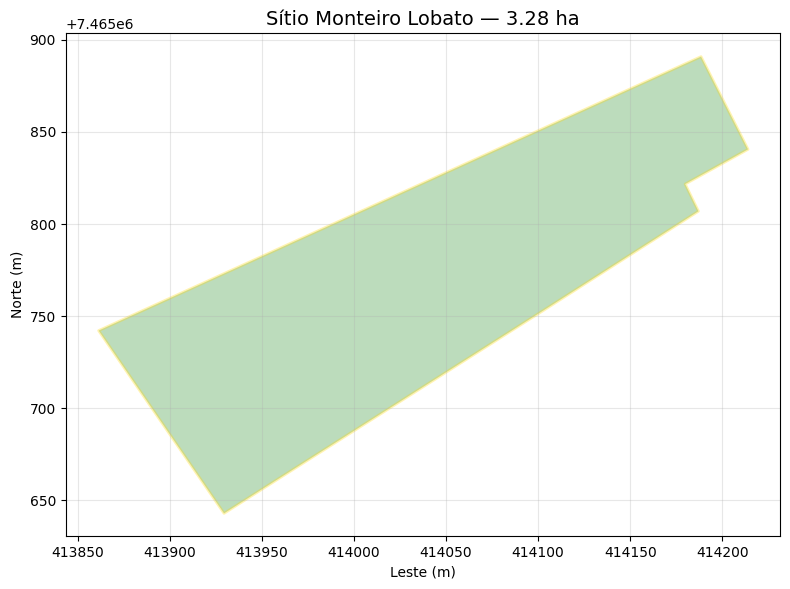

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
gdf_utm.plot(ax=ax, edgecolor="#FFD700", facecolor="#228B22", alpha=0.3, linewidth=2)
ax.set_title(f"Sítio Monteiro Lobato — {area_m2/10_000:.2f} ha", fontsize=14)
ax.set_xlabel("Leste (m)")
ax.set_ylabel("Norte (m)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Exportar mapa como HTML

Salvamos o mapa interativo como arquivo HTML para compartilhar ou embutir no dashboard.

In [5]:
output_path = "../data/mapa_sitio.html"
mapa.save(output_path)
print(f"Mapa salvo em: {output_path}")

Mapa salvo em: ../data/mapa_sitio.html


## Próximos passos

- **Módulo 2:** Calcular NDVI com imagens Sentinel-2 para avaliar saúde da vegetação
- **Módulo 3:** Cruzar dados de solo, declividade e clima para modelo de aptidão agrícola
- **Dashboard:** Integrar este mapa no painel Streamlit